# Regression part A

In [2]:
from ExtractData import *
import matplotlib.pyplot as plt
from sklearn import model_selection, linear_model as lm
from dtuimldmtools import rlr_validate, train_neural_net, draw_neural_net
import scipy.stats as st
import torch
from sklearn.preprocessing import StandardScaler

The original data matrix has shape: (1007, 8)


In [4]:
# One-hot encoding categorical variables
df_encoded = pd.get_dummies(
    df, columns=["Car Make", "Country"], drop_first=False, dtype=int
)
# print(df_encoded.describe(include="all"))

# Extract target and features
y = df_encoded["Price (in USD)"].to_numpy()
X = df_encoded.drop(["Price (in USD)"], axis=1).to_numpy()
X = np.nan_to_num(X).astype(float)

# Add bias term (offset)
X = np.hstack([np.ones((X.shape[0], 1)), X])
attributeNames = [
    "Offset",
    "Year",
    "Engine Size (L)",
    "Horsepower",
    "Torque (lb-ft)",
    "0-60 MPH Time (seconds)",
    "Car Make",
    "Country",
]
N, M = X.shape
print(f"Number of samples: {N}")
print(f"Number of attributes: {M}")
# print(X[0, :])
# print(X[0, 6:])
# print(X[0, 1:6]) # Values except for the offset
# print(X[0, -10:]) #  Counties
# print(X[0, 6:44]) # Car Makes

Number of samples: 1007
Number of attributes: 54


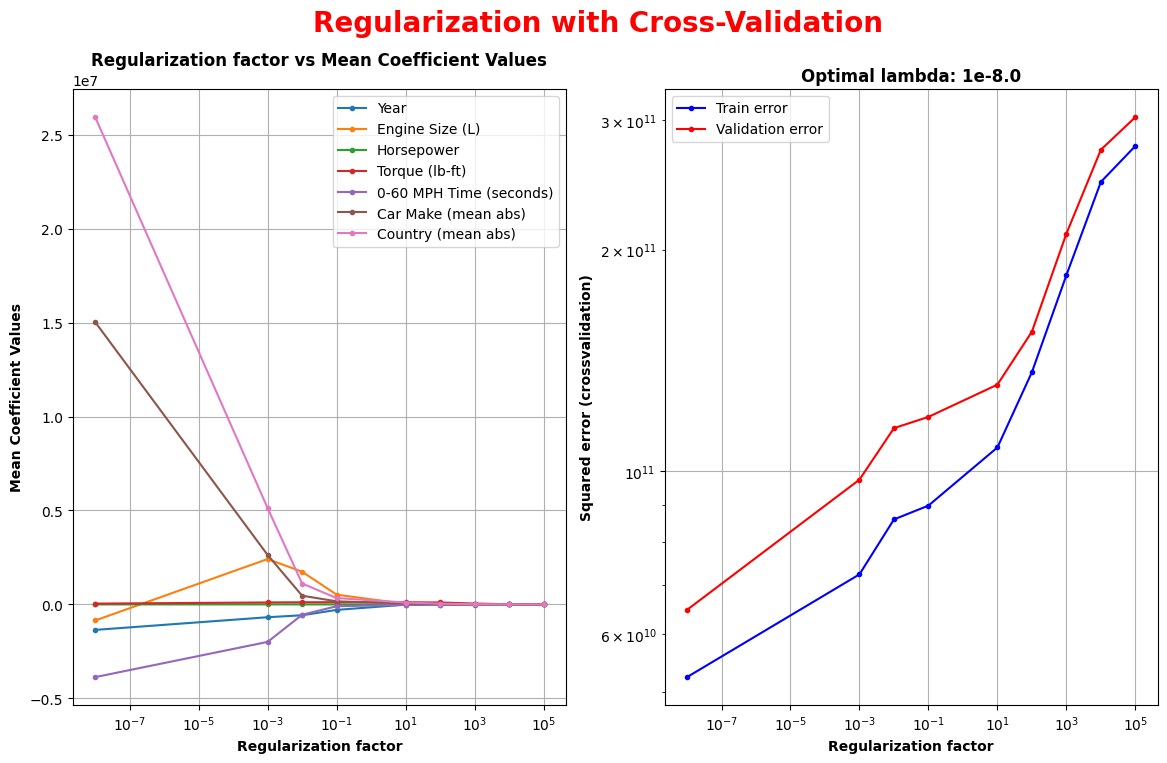

Linear regression without feature selection:
- Training error: 51984779384.20037
- Test error:     4.3370952660375996e+49
- R^2 train:     0.9045336792965402
- R^2 test:     -8.016502465170701e+37

Regularized linear regression:
- Training error: 51809420840.75318
- Test error:     65124552537.02659
- R^2 train:     0.9048557126906438
- R^2 test:     0.8796265463559485

Weights in last fold:
         Offset       378265.59
           Year       -66654.96
Engine Size (L)       -37481.12
     Horsepower        10222.12
 Torque (lb-ft)       201091.64
0-60 MPH Time (seconds)       -54434.53
       Car Make       -22535.21
        Country       -34109.37


In [ ]:
## Crossvalidation
# Create crossvalidation partition for evaluation
K = 10
CV = model_selection.KFold(K, shuffle=True)

lambdas = np.array(
    [1e-8, 10**-3, 10**-2, 10**-1, 10**1, 10**2, 10**3, 10**4, 10**5], dtype=float
)

Error_train = np.empty((K, 1))
Error_test = np.empty((K, 1))
Error_train_rlr = np.empty((K, 1))
Error_test_rlr = np.empty((K, 1))
Error_train_nofeatures = np.empty((K, 1))
Error_test_nofeatures = np.empty((K, 1))
w_rlr = np.empty((M, K))
mu = np.empty((K, M - 1))
sigma = np.empty((K, M - 1))
w_noreg = np.empty((M, K))


k = 0
for train_index, test_index in CV.split(X, y):

    # extract training and test set for current CV fold
    X_train = X[train_index]
    y_train = y[train_index]
    X_test = X[test_index]
    y_test = y[test_index]
    internal_cross_validation = 10

    (
        opt_val_err,
        opt_lambda,
        mean_w_vs_lambda,
        train_err_vs_lambda,
        test_err_vs_lambda,
    ) = rlr_validate(X_train, y_train, lambdas, internal_cross_validation)

    # Standardize outer fold based on training set, and save the mean and standard
    # deviations since they're part of the model (they would be needed for
    # making new predictions) - for brevity we won't always store these in the scripts
    mu[k, :] = np.mean(X_train[:, 1:], 0)
    sigma[k, :] = np.std(X_train[:, 1:], 0)

    epsilon = 1e-8  # Small constant to prevent divide-by-zero errors
    safe_sigma = np.where(sigma[k, :] == 0, epsilon, sigma[k, :])

    X_train[:, 1:] = (X_train[:, 1:] - mu[k, :]) / safe_sigma
    X_test[:, 1:] = (X_test[:, 1:] - mu[k, :]) / safe_sigma

    Xty = X_train.T @ y_train
    XtX = X_train.T @ X_train

    # Compute mean squared error without using the input data at all
    Error_train_nofeatures[k] = (
        np.square(y_train - y_train.mean()).sum(axis=0) / y_train.shape[0]
    )
    Error_test_nofeatures[k] = (
        np.square(y_test - y_test.mean()).sum(axis=0) / y_test.shape[0]
    )

    # Estimate weights for the optimal value of lambda, on entire training set
    lambdaI = opt_lambda * np.eye(M)
    lambdaI[0, 0] = 0  # Do no regularize the bias term
    w_rlr[:, k] = np.linalg.solve(XtX + lambdaI, Xty).squeeze()
    # Compute mean squared error with regularization with optimal lambda
    Error_train_rlr[k] = (
        np.square(y_train - X_train @ w_rlr[:, k]).sum(axis=0) / y_train.shape[0]
    )
    Error_test_rlr[k] = (
        np.square(y_test - X_test @ w_rlr[:, k]).sum(axis=0) / y_test.shape[0]
    )

    # Estimate weights for unregularized linear regression, on entire training set
    AvoidCrash = 1e-8 * np.eye(M)
    AvoidCrash[0, 0] = 0  # Do no regularize the bias term
    w_noreg[:, k] = np.linalg.solve(
        XtX + AvoidCrash, Xty
    ).squeeze()  # TODO: ADD HERE SMALL REGULARIZATION TERM FOR NUMERICAL STABILITY
    # Compute mean squared error without regularization
    # Error_train[k] = np.square(y_train-X_train @ w_noreg[:,k]).sum(axis=0)/y_train.shape[0]
    # Error_test[k] = np.square(y_test-X_test @ w_noreg[:,k]).sum(axis=0)/y_test.shape[0]
    # OR ALTERNATIVELY: you can use sklearn.linear_model module for linear regression:
    m = lm.LinearRegression().fit(X_train, y_train)
    Error_train[k] = np.square(y_train - m.predict(X_train)).sum() / y_train.shape[0]
    Error_test[k] = np.square(y_test - m.predict(X_test)).sum() / y_test.shape[0]

    # Display the results for the last cross-validation fold
    if k == K - 1:
        plt.figure(k, figsize=(14, 8))
        plt.subplot(1, 2, 1)
        # plt.semilogx(
        #     lambdas, mean_w_vs_lambda.T[:, 1:6], ".-"
        # )  # Don't plot the bias term
        # plt.xlabel("Regularization factor", fontweight="bold")
        # plt.ylabel("Mean Coefficient Values", fontweight="bold")
        # plt.title("Regularization factor vs Mean Coefficient Values", fontweight="bold")
        # plt.grid()
        # # You can choose to display the legend, but it's omitted for a cleaner
        # # plot, since there are many attributes
        # plt.legend(attributeNames[1:], loc="best")
        # Plot the mean coefficient values for continuous features (as before)
        plt.semilogx(lambdas, mean_w_vs_lambda.T[:, 1:6], ".-")

        # Aggregate mean absolute coefficient values for Car Makes and Countries
        car_make_effect = np.mean(np.abs(mean_w_vs_lambda.T[:, 6:44]), axis=1)
        country_effect = np.mean(np.abs(mean_w_vs_lambda.T[:, -10:]), axis=1)

        # Plot the aggregated effects for Car Makes and Countries
        plt.semilogx(lambdas, car_make_effect, ".-", label="Car Make (mean abs)")
        plt.semilogx(lambdas, country_effect, ".-", label="Country (mean abs)")

        # Add labels and title
        plt.xlabel("Regularization factor", fontweight="bold")
        plt.ylabel("Mean Coefficient Values", fontweight="bold")
        plt.title("Regularization factor vs Mean Coefficient Values", fontweight="bold")
        plt.grid()

        # Legend including the continuous attribute names and new labels for aggregated effects
        plt.legend(
            attributeNames[1:6] + ["Car Make (mean abs)", "Country (mean abs)"],
            loc="best",
        )

        plt.subplot(1, 2, 2)
        plt.title(
            "Optimal lambda: 1e{0}".format(np.log10(opt_lambda)), fontweight="bold"
        )
        plt.loglog(
            lambdas, train_err_vs_lambda.T, "b.-", lambdas, test_err_vs_lambda.T, "r.-"
        )
        plt.xlabel("Regularization factor", fontweight="bold")
        plt.ylabel("Squared error (crossvalidation)", fontweight="bold")
        plt.legend(["Train error", "Validation error"])
        plt.grid()
        plt.suptitle(
            "Regularization with Cross-Validation",
            fontsize=20,
            fontweight="bold",
            color="red",
        )
        plt.show()

    # To inspect the used indices, use these print statements
    # print('Cross validation fold {0}/{1}:'.format(k+1,K))
    # print('Train indices: {0}'.format(train_index))
    # print('Test indices: {0}\n'.format(test_index))

    k += 1


# Display results
print("Linear regression without feature selection:")
print("- Training error: {0}".format(Error_train.mean()))
print("- Test error:     {0}".format(Error_test.mean()))
print(
    "- R^2 train:     {0}".format(
        (Error_train_nofeatures.sum() - Error_train.sum())
        / Error_train_nofeatures.sum()
    )
)
print(
    "- R^2 test:     {0}\n".format(
        (Error_test_nofeatures.sum() - Error_test.sum()) / Error_test_nofeatures.sum()
    )
)
print("Regularized linear regression:")
print("- Training error: {0}".format(Error_train_rlr.mean()))
print("- Test error:     {0}".format(Error_test_rlr.mean()))
print(
    "- R^2 train:     {0}".format(
        (Error_train_nofeatures.sum() - Error_train_rlr.sum())
        / Error_train_nofeatures.sum()
    )
)
print(
    "- R^2 test:     {0}\n".format(
        (Error_test_nofeatures.sum() - Error_test_rlr.sum())
        / Error_test_nofeatures.sum()
    )
)

print("Weights in last fold:")
for m in range(len(attributeNames)):
    print("{:>15} {:>15}".format(attributeNames[m], np.round(w_rlr[m, -1], 2)))

# PART B

In [10]:
continuous_columns = [
    "Year",
    "Engine Size (L)",
    "Horsepower",
    "Torque (lb-ft)",
    "0-60 MPH Time (seconds)",
    "Price (in USD)",
]
one_hot_columns = df_encoded.columns.difference(continuous_columns).tolist()

# Standardize continuous features
scaler = StandardScaler()
df_encoded[continuous_columns] = scaler.fit_transform(df_encoded[continuous_columns])
# print(df_encoded.describe(include="all"))

# Extract target and features
y = df_encoded["Price (in USD)"].to_numpy()
X = df_encoded.drop(["Price (in USD)"], axis=1).to_numpy()
X = np.nan_to_num(X).astype(float)

# Add bias term (offset)
X = np.hstack([np.ones((X.shape[0], 1)), X])
attributeNames = [
    "Offset",
    "Car Make",
    "Year",
    "Horsepower",
    "Torque (lb-ft)",
    "0-60 MPH Time (seconds)",
    "Country",
]

N, M = X.shape
print(f"Number of samples: {N}")
print(f"Number of attributes: {M}")

Number of samples: 1007
Number of attributes: 54


In [11]:
# Parameters for neural network classifier
n_hidden_units = 10  # number of hidden units
n_replicates = 1  # number of networks trained in each k-fold
max_iter = 10000
model_parameter = np.array([1, 2, 4, 8, 16])

K_Outer = 10
CV_Outer = model_selection.KFold(n_splits=K_Outer, shuffle=True)

loss_fn = torch.nn.MSELoss()  # notice how this is now a mean-squared-error loss

errors = []  # make a list for storing generalizaition error in each loop


lambdas = np.array(
    [10**-3, 10**-2, 10**-1, 10**1, 10**2, 10**3, 10**4, 10**5], dtype=float
)
# lambdas = [np.power(10., i) for i in range(-3, 4)]


for k_out, (train_index_outer, test_index_outer) in enumerate(CV_Outer.split(X, y)):
    print("\n Crossvalidation fold (outer): {0}/{1}".format(k_out + 1, K_Outer))

    # For the PyTorch neural network
    X_train_outer_network = torch.Tensor(X[train_index_outer, :])
    y_train_outer_network = torch.Tensor(y[train_index_outer])
    X_test_outer_network = torch.Tensor(X[test_index_outer, :])
    y_test_outer_network = torch.Tensor(y[test_index_outer])

    # For the linear regression model
    X_train_outer_regression = X[train_index_outer, :]
    y_train_outer_regression = y[train_index_outer]
    X_test_outer_regression = X[test_index_outer, :]
    y_test_outer_regression = y[test_index_outer]

    j = 0

    errors_outer = np.zeros([len(model_parameter), 10])
    errors_inner = np.zeros([len(model_parameter), 10])

    K_Inner = 10
    CV_Inner = model_selection.KFold(n_splits=K_Inner, shuffle=True)

    for k_in, (train_index_2, test_index_2) in enumerate(
        CV_Inner.split(X_train_outer_regression, y_train_outer_regression)
    ):
        print("\n Crossvalidation fold (inner): {0}/{1}".format(k_in + 1, K_Inner))

        # For the PyTorch neural network
        X_train_inner_network = torch.Tensor(X_train_outer_network[train_index_2, :])
        y_train_inner_network = torch.Tensor(y_train_outer_network[train_index_2]).view(
            -1, 1
        )
        X_test_inner_network = torch.Tensor(X_train_outer_network[test_index_2, :])
        y_test_inner_network = torch.Tensor(y_train_outer_network[test_index_2]).view(
            -1, 1
        )

        # For the linear regression model
        X_train_inner_regression = X_train_outer_regression[train_index_2, :]
        y_train_inner_regression = y_train_outer_regression[train_index_2]
        X_test_inner_regression = X_train_outer_regression[test_index_2, :]
        y_test_inner_regression = y_train_outer_regression[test_index_2]

        i = 0

        # precompute terms
        Xty = X_train_inner_regression.T @ y_train_inner_regression
        XtX = X_train_inner_regression.T @ X_train_inner_regression

        for n_hidden_units in model_parameter:
            model = lambda: torch.nn.Sequential(
                torch.nn.Linear(M, n_hidden_units),  # M features to n_hidden_units
                torch.nn.Tanh(),  # 1st transfer function,
                torch.nn.Linear(n_hidden_units, 1),  # n_hidden_units to 1 output neuron
                # no final tranfer function, i.e. "linear output"
            )
            net, final_loss, learning_curve = train_neural_net(
                model,
                loss_fn,
                X=X_train_inner_network,
                y=y_train_inner_network,
                n_replicates=n_replicates,
                max_iter=max_iter,
                tolerance=1e-15,
            )

            print("\n\tBest loss: {}\n".format(final_loss))

            # Determine estimated class labels for test set
            y_test_est = net(X_test_inner_network)

            se = (
                y_test_est.float() - y_test_inner_network.float()
            ) ** 2  # squared error

            mse_inner = (
                sum(se).type(torch.float) / len(y_test_inner_network)
            ).data.numpy()  # mean

            errors_inner[i, j] = mse_inner.item()
            i += 1

        errors_outer[:, j] = errors_outer[:, j] / len(y_train_outer_regression)
        errors_inner[:, j] = errors_inner[:, j] / len(y_train_outer_regression)

        j += 1

    print(
        "\n"
        + "The result for the outer crossvalidation fold {}".format(k_out + 1)
        + " is:"
        + "\n"
    )

    error_model_outer = np.sum(errors_outer, axis=1)
    lamda = lambdas[np.argmin(error_model_outer)]

    m = lm.Ridge(alpha=lamda).fit(X_train_outer_regression, y_train_outer_regression)
    error_lambda = np.square(
        y_test_outer_regression - m.predict(X_test_outer_regression)
    ).sum() / len(y_test_outer_regression)
    print("Linear regression (lambda-value and the error)", lamda, error_lambda)

    error_model_inner = np.sum(errors_inner, axis=1)
    lamda = model_parameter[np.argmin(error_model_inner)]

    m_2 = lambda: torch.nn.Sequential(
        torch.nn.Linear(M, lamda),  # M features to n_hidden_units
        torch.nn.Tanh(),  # 1st transfer function,
        torch.nn.Linear(lamda, 1),  # n_hidden_units to 1 output neuron
        # no final tranfer function, i.e. "linear output"
    )

    net_2, final_loss_2, learning_curve_2 = train_neural_net(
        m_2,
        loss_fn,
        X=X_train_outer_network,
        y=y_train_outer_network,
        n_replicates=n_replicates,
        max_iter=max_iter,
        tolerance=1e-15,
    )

    y_test_est_2 = net_2(X_test_outer_network)

    se_2 = (y_test_est_2.float() - y_test_outer_network.float()) ** 2  # squared error
    mse_2 = (
        sum(se_2).type(torch.float) / len(y_test_outer_network)
    ).data.numpy()  # mean
    print("ANN (h-value and the error)", lamda, mse_2)

    m3 = sum(y_train_outer_regression) / len(y_train_outer_regression)
    errorBase = np.square(y_test_outer_regression - m3).sum() / len(
        y_test_outer_regression
    )
    print("BASE (the error)", errorBase)
    print("\n")

    z_A = np.abs(y_test_outer_regression - m.predict(X_test_outer_regression)) ** 2
    z_B = np.abs(y_test_outer_network - y_test_est_2.data.numpy()) ** 2
    z_B = (z_B).data.numpy()
    z_C = np.abs(y_test_outer_regression - m3) ** 2

    alpha = 0.05
    z_1 = z_A - z_B
    z_2 = z_A - z_C
    z_3 = z_B - z_C

    z_hat_1 = sum(z_1) / len(y_test_outer_network)
    z_hat_2 = sum(z_2) / len(y_test_outer_network)
    z_hat_3 = sum(z_3) / len(y_test_outer_network)

    CI_1 = st.t.interval(1 - alpha, len(z_1) - 1, loc=np.mean(z_1), scale=st.sem(z_1))
    CI_2 = st.t.interval(1 - alpha, len(z_2) - 1, loc=np.mean(z_2), scale=st.sem(z_2))
    CI_3 = st.t.interval(1 - alpha, len(z_3) - 1, loc=np.mean(z_3), scale=st.sem(z_3))

    p_1 = 2 * st.t.cdf(-np.abs(np.mean(z_1)) / st.sem(z_1), df=len(z_1) - 1)  # p-value
    p_2 = 2 * st.t.cdf(-np.abs(np.mean(z_2)) / st.sem(z_2), df=len(z_2) - 1)  # p-value
    p_3 = 2 * st.t.cdf(-np.abs(np.mean(z_3)) / st.sem(z_3), df=len(z_3) - 1)  # p-value

    print(
        "Z_hat value for comparing ANN and linear regression:                 ", z_hat_1
    )
    print(
        "Z_hat value for comparing ANN and baseline:                          ", z_hat_3
    )
    print(
        "Z_hat value for comparing linear regression and baseline:            ", z_hat_2
    )
    print("\n")
    print("Confidence Interval for comparing ANN and linear regression:         ", CI_1)
    print("Confidence Interval for comparing ANN and baseline:                  ", CI_3)
    print("Confidence Interval for comparing linear regression and baseline:    ", CI_2)
    print("\n")
    print("P value for comparing ANN and linear regression:                     ", p_1)
    print("P value for comparing ANN and baseline:                              ", p_3)
    print("P value for comparing linear regression and baseline:                ", p_2)


 Crossvalidation fold (outer): 1/10

 Crossvalidation fold (inner): 1/10

	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	0.11157881	0.00077198056
		2000	0.08368581	9.213797e-05
		3000	0.06975197	0.00036474812
		4000	0.051260695	0.0001443086
		5000	0.047223214	4.685659e-05
		6000	0.045691665	2.2665123e-05
		7000	0.044962026	1.0688071e-05
		8000	0.0446512	3.9212377e-06
		9000	0.044541188	1.1709163e-06
		10000	0.044507258	4.185035e-07
		Final loss:
		10000	0.044507258	4.185035e-07

	Best loss: 0.044507257640361786


	Replicate: 1/1
		Iter	Loss			Rel. loss
		1000	0.11030467	0.0013816897
		2000	0.052893985	0.00029149262
		3000	0.046247274	6.790036e-05
		4000	0.044023346	2.8008697e-05
		5000	0.043178618	1.440793e-05
		6000	0.042452376	2.3341547e-05
		7000	0.040762693	4.9896287e-05
		8000	0.039811946	7.953571e-06
		9000	0.0396605	2.3482316e-06
		10000	0.03956732	1.4122583e-06
		Final loss:
		10000	0.03956732	1.4122583e-06

	Best loss: 0.03956732153892517


	Replicate: 1/1
		Iter	Loss			Rel. 